# 📊 OFF BALL RUN VISUALIZATION

This notebook demonstrates how to use the radar plot from skillcorner viz with the new schema of Game Intelligence 2.0, for Off Ball Runs in particular

## 📋 Step 1: Libraries and Path Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from skillcorner.client import SkillcornerClient

# Add the src directory to the path so we can import the visualization module
sys.path.append(os.path.abspath('../../../src'))

## 📥 Step 2: Load Data

We will load the AUS A-League physical aggregates for the 2024/2025 season.

In [ ]:
data_path = '../../../data/aggregates/aus1league_obraggregates_20242025.csv'
df = pd.read_csv(data_path)

# Use the below process if you have SkillCorner Credentials and want more data 

# client=SkillcornerClient(username=XXX,password=XXX')
# response=client.get_metrics_gi_ip_off_ball_runs(params={'competition_edition': '387,390',
#                                                'group_by':'player,competition_edition,position_group',
#                                                'variants':'obr_type',
#                                                'playing_time__gte':'60',
#                                                'average_per':'p30tip'
#                                                })
#
# df=pd.DataFrame(response)

print(f"Loaded {len(df)} rows")
df.head()

Loaded 407 rows


,competition_edition_id,competition_id,competition_name,season_id,season_name,player_id,player_name,player_short_name,player_birthdate,team_id,...,behindrun_count_dangerous_received_p30tip,comingshortrun_count_dangerous_received_p30tip,crossreceiverrun_count_dangerous_received_p30tip,droppingoffrun_count_dangerous_received_p30tip,overlaprun_count_dangerous_received_p30tip,pullinghalfspacerun_count_dangerous_received_p30tip,pullingwiderun_count_dangerous_received_p30tip,aheadoftheballrun_count_dangerous_received_p30tip,supportrun_count_dangerous_received_p30tip,underlaprun_count_dangerous_received_p30tip
0,870,61,AUS - A-League,95,2024/2025,211,Adam Taggart,A. Taggart,1993-06-02,871,...,1.62,0.0,1.11,0.0,0.0,0.0,0.0,1.21,0.40,0.0
1,870,61,AUS - A-League,95,2024/2025,218,Adama Traoré,A. Traoré,1990-02-03,868,...,0.00,0.0,0.57,0.0,0.0,0.0,0.0,0.57,0.00,0.0
2,870,61,AUS - A-League,95,2024/2025,2759,Dino Arslanagić,D. Arslanagić,1993-04-24,1804,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.16,0.00,0.0
3,870,61,AUS - A-League,95,2024/2025,2858,Douglas Costa de Souza,Douglas Costa,1990-09-14,869,...,0.71,0.0,0.00,0.0,0.0,0.0,0.0,0.35,0.35,0.0
4,870,61,AUS - A-League,95,2024/2025,2858,Douglas Costa de Souza,Douglas Costa,1990-09-14,869,...,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0


## 📂 Step 3: Normalization and Filtering

Matching the approach in the Z-score tutorial, we perform the following:
1. Filter for players with at least 5 matches.

In this example the data is already normalized so no need to do other operations

In [16]:
# Initial filtering
df_filtered = df[(df['performance_count'] >= 5)].copy()

print(f"Data filtered to {len(df_filtered)} records and normalized.")

Data filtered to 194 records and normalized.


## 📊 Step 4: Visualization Setup

We need to define:
1. **Questions**: A dictionary mapping section labels to lists of metrics.
2. **Highlight Group**: The list of players we want to display in the table.

In [17]:
from skillcornerviz.standard_plots import radar_plot as rad

RUNS = {'crossreceiverrun_count_p30tip': 'Cross Receiver',
        'behindrun_count_p30tip': ' In Behind',
        'aheadoftheballrun_count_p30tip': 'Ahead Of The Ball',
        'overlaprun_count_p30tip': 'Overlap',
        'underlaprun_count_p30tip': 'Underlap',
        'supportrun_count_p30tip': 'Support',
        'comingshortrun_count_p30tip': 'Coming Short',
        'droppingoffrun_count_p30tip': 'Dropping Off',
        'pullinghalfspacerun_count_p30tip': 'Pulling Half-Space',
        'pullingwiderun_count_p30tip': 'Pulling Wide'}


## 🎨 Step 5: Render the Sectioned Summary Table

/Users/nano/PycharmProjects/opendata/venv/lib/python3.10/site-packages/skillcornerviz/utils/skillcorner_utils.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[metric + '_pct'] = (df[metric].rank(pct=True, na_option='keep') * 100).round()
/Users/nano/PycharmProjects/opendata/venv/lib/python3.10/site-packages/skillcornerviz/utils/skillcorner_utils.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[metric + '_pct'] = (df[metric].rank(pct=True, na_option='keep') * 100).round()
/Users/nano/PycharmP

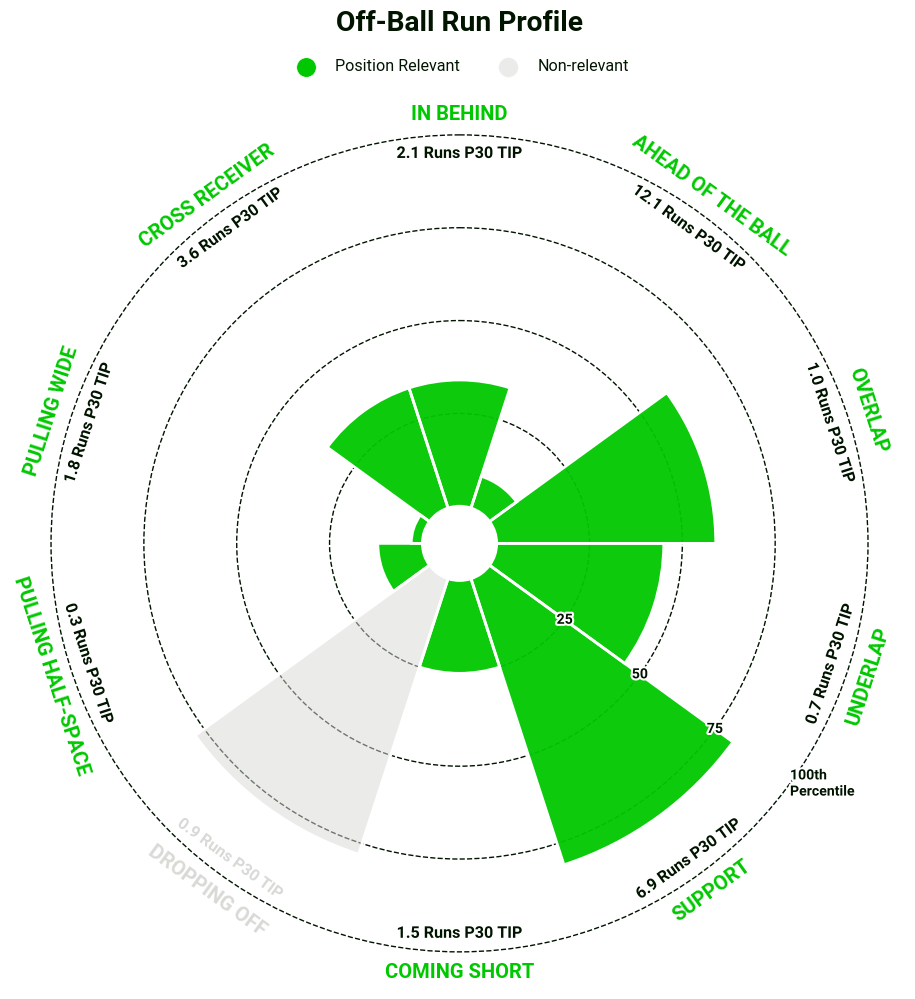

In [24]:
runs_df=df_filtered.copy()

fig, ax = rad.plot_radar(runs_df[runs_df['position_group'] == 'Wide Attacker'],
                         data_point_id='player_id',
                         label=18573, # Whcih data_point_id to highlight. If you use a name, use player_name as data_point_id
                         plot_title='Off-Ball Run Profile',
                         metrics=RUNS.keys(),
                         metric_labels=RUNS,
                         percentiles_precalculated=False, # Add this to make sure you visualize percentiles
                         suffix=' Runs P30 TIP',
                         filter_relevant=True, # Only color the run types that are important to you group like user group

                         # Create your own sample text
                         # positions='Wide Attackers',
                         # matches=5,
                         # minutes=60,
                         # competitions='AUS1',
                         # seasons='2024/2025', 
                         # add_sample_info=True
                         )